In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch05_checkpoints"

In [3]:
batches, train_losses, val_losses, created_at = [], [], [], []

json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    batch = f.name.replace("checkpoint_", "").replace(".json", "")
    batches.append(int(batch))
    train_losses.append(data['train_loss'])
    val_losses.append(data['validation_loss'])
    created_at.append(data['created_at'])

In [4]:
df = pd.DataFrame({
    "batches": batches,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "created_at": created_at,
})


df = df.sort_values(by='batches', ascending=True)

print(df.nsmallest(1, 'train_loss'))

df.to_csv(checkpoint_dir / "trainning.tsv", index=False, sep='\t')

pd.concat((df.head(10), df.tail(20)))

    batches  train_loss  val_loss                 created_at
31       65    2.737065  4.278061  2025-09-04T13:59:33+08:00


,batches,train_loss,val_loss,created_at
34,1,3.741819,4.835101,2025-09-03T17:17:39+08:00
26,2,3.815401,4.946927,2025-09-03T17:32:54+08:00
39,3,3.813940,4.966991,2025-09-03T17:48:07+08:00
19,4,4.010565,5.191225,2025-09-03T18:03:21+08:00
71,5,3.951771,5.168334,2025-09-03T18:18:36+08:00
66,6,3.980617,5.214966,2025-09-03T18:33:51+08:00
16,7,3.942023,5.180028,2025-09-03T18:49:06+08:00
48,8,3.929550,5.195697,2025-09-03T19:04:20+08:00
7,9,3.715622,4.987008,2025-09-03T19:19:35+08:00
67,10,3.618894,4.926662,2025-09-03T19:34:50+08:00


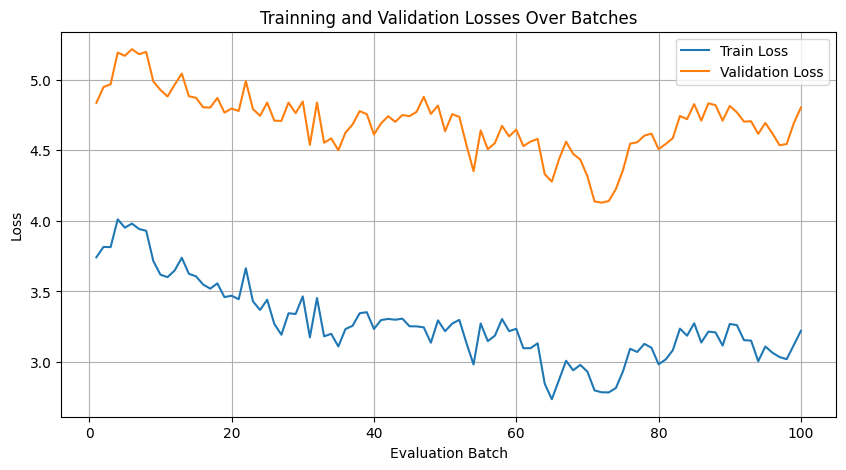

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['batches'], df['train_loss'], label="Train Loss")
plt.plot(df['batches'], df['val_loss'], label="Validation Loss")
plt.xlabel("Evaluation Batch")
plt.ylabel("Loss")
plt.title("Trainning and Validation Losses Over Batches")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "trainning.pdf")